# Model Evaluation and Exploration

This notebook explores the different recommendation models implemented in the `WatchNext` project and evaluates their performance using standard information retrieval metrics.

## Objectives
1. Load and inspect the dataset.
2. Explore the Content-Based, Collaborative Filtering, and Hybrid recommenders.
3. Run a comprehensive evaluation pipeline to compare model performance.
4. Visualize key metrics like Precision@K, Recall@K, and Novelty.

In [1]:
import sys
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Add project root to sys.path to import watchnext modules
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from watchnext.common import get_paths
from watchnext.data_loader import load_raw_data
from watchnext.evaluation.metrics import (
    coverage,
    mae,
    ndcg_at_k,
    novelty,
    precision_at_k,
    recall_at_k,
    rmse,
    temporal_train_test_split,
)
from watchnext.models.collaborative_filtering import score_user_items as cf_score_user_items
from watchnext.models.content_based import recommend_similar
from watchnext.models.hybrid_recommender import HybridRecommender

## 1. Data Loading

We load the MovieLens dataset using our standard data loader.

In [2]:
dataset = load_raw_data()
movies = dataset["movies"]
ratings = dataset["ratings"]

print(f"Loaded {len(movies)} movies and {len(ratings)} ratings.")
display(movies.head())
display(ratings.head())

Loaded 9742 movies and 100836 ratings.


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 2. Train-Test Split

We use a temporal split to ensure we evaluate the models on future interactions, avoiding data leakage.

In [3]:
train_ratings, test_ratings = temporal_train_test_split(ratings, test_fraction=0.2)
print(f"Training set size: {len(train_ratings)}")
print(f"Test set size: {len(test_ratings)}")

Training set size: 80668
Test set size: 20168


## 3. Model Exploration

### Content-Based Filtering
Recommending similar movies based on genres and tags.

In [4]:
sample_movie_id = movies.iloc[0]["movieId"]
sample_movie_title = movies.iloc[0]["title"]
print(f"Recommendations for: {sample_movie_title} (ID: {sample_movie_id})")

content_recs = recommend_similar(sample_movie_id, top_n=5)
pd.DataFrame(content_recs)

Recommendations for: Toy Story (1995) (ID: 1)


,movieId,title,score
0,3114,Toy Story 2 (1999),0.929545
1,2294,Antz (1998),0.912871
2,4016,"Emperor's New Groove, The (2000)",0.912871
3,53121,Shrek the Third (2007),0.912871
4,65577,"Tale of Despereaux, The (2008)",0.912871


### Collaborative Filtering
Predicting user interest based on past behavior of similar users.

In [5]:
sample_user_id = ratings.iloc[0]["userId"]
candidate_movie_ids = movies["movieId"].head(10).tolist()

cf_scores = cf_score_user_items(sample_user_id, candidate_movie_ids)
cf_results = pd.DataFrame({
    "movieId": cf_scores.index,
    "predicted_rating": cf_scores.values
}).merge(movies[["movieId", "title"]], on="movieId")

cf_results.sort_values("predicted_rating", ascending=False)

,movieId,predicted_rating,title
0,1,2.488819,Toy Story (1995)
5,6,2.435360,Heat (1995)
9,10,1.637133,GoldenEye (1995)
1,2,1.078774,Jumanji (1995)
2,3,0.691712,Grumpier Old Men (1995)
8,9,0.186277,Sudden Death (1995)
7,8,-0.072961,Tom and Huck (1995)
3,4,-0.089454,Waiting to Exhale (1995)
4,5,-0.512698,Father of the Bride Part II (1995)
6,7,-0.886549,Sabrina (1995)


### Hybrid Recommender
Combining content and collaborative signals.

In [6]:
hybrid = HybridRecommender(ratings_frame=train_ratings)
hybrid_recs = hybrid.recommend(sample_user_id, top_n=5)
pd.DataFrame(hybrid_recs)

,movieId,title,score
0,1036,Die Hard (1988),0.811437
1,2683,Austin Powers: The Spy Who Shagged Me (1999),0.723753
2,380,True Lies (1994),0.721667
3,588,Aladdin (1992),0.714329
4,1200,Aliens (1986),0.697398


## 4. Comprehensive Evaluation Pipeline

This section implements the evaluation logic found in `evaluate_models.py`.

In [7]:
def run_evaluation(k=10, num_test_users=50):
    test_users = test_ratings["userId"].drop_duplicates().tolist()[:num_test_users]
    popularity = train_ratings.groupby("movieId").size()
    hybrid_model = HybridRecommender(ratings_frame=train_ratings)
    catalog_size = movies["movieId"].nunique()

    results = {"content": [], "cf": [], "hybrid": []}
    metrics_summary = {
        model: {"precision": [], "recall": [], "ndcg": [], "recs": []} 
        for model in ["content", "cf", "hybrid"]
    }

    for user_id in test_users:
        # Ground truth: movies user rated >= 4.0 in test set
        relevant_items = set(test_ratings.loc[
            (test_ratings["userId" ] == user_id) & (test_ratings["rating"] >= 4.0), "movieId"
        ].tolist())
        
        if not relevant_items:
            continue

        # CF Recs
        all_movie_ids = movies["movieId"].tolist()
        cf_scores = cf_score_user_items(user_id, all_movie_ids)
        cf_top = cf_scores.sort_values(ascending=False).head(k).index.tolist()

        # Hybrid Recs
        hybrid_top = [row["movieId"] for row in hybrid_model.recommend(user_id, top_n=k)]

        # Content Recs (based on user's first movie in train set)
        user_train = train_ratings[train_ratings["userId"] == user_id]
        seen_movie = user_train["movieId"].iloc[0] if not user_train.empty else movies["movieId"].iloc[0]
        content_top = [row["movieId"] for row in recommend_similar(int(seen_movie), top_n=k)]

        # Store metrics
        model_recs = {"content": content_top, "cf": cf_top, "hybrid": hybrid_top}
        for model_name, recs in model_recs.items():
            metrics_summary[model_name]["precision"].append(precision_at_k(relevant_items, recs, k))
            metrics_summary[model_name]["recall"].append(recall_at_k(relevant_items, recs, k))
            metrics_summary[model_name]["ndcg"].append(ndcg_at_k(relevant_items, recs, k))
            metrics_summary[model_name]["recs"].append(recs)

    # Final Aggregation
    final_report = {}
    for model_name in ["content", "cf", "hybrid"]:
        final_report[model_name] = {
            "Precision@K": np.mean(metrics_summary[model_name]["precision"]),
            "Recall@K": np.mean(metrics_summary[model_name]["recall"]),
            "NDCG@K": np.mean(metrics_summary[model_name]["ndcg"]),
            "Coverage": coverage(metrics_summary[model_name]["recs"], catalog_size),
            "Novelty": novelty(metrics_summary[model_name]["recs"], popularity)
        }
    
    return pd.DataFrame(final_report).T

evaluation_results = run_evaluation(k=10, num_test_users=50)
evaluation_results

,Precision@K,Recall@K,NDCG@K,Coverage,Novelty
content,0.030,0.002396,0.040691,0.016732,13.672238
cf,0.476,0.091553,0.490277,0.017245,9.577457
hybrid,0.176,0.062481,0.188425,0.018066,14.274586


## 5. Visualization

Comparing the models visually across key metrics.

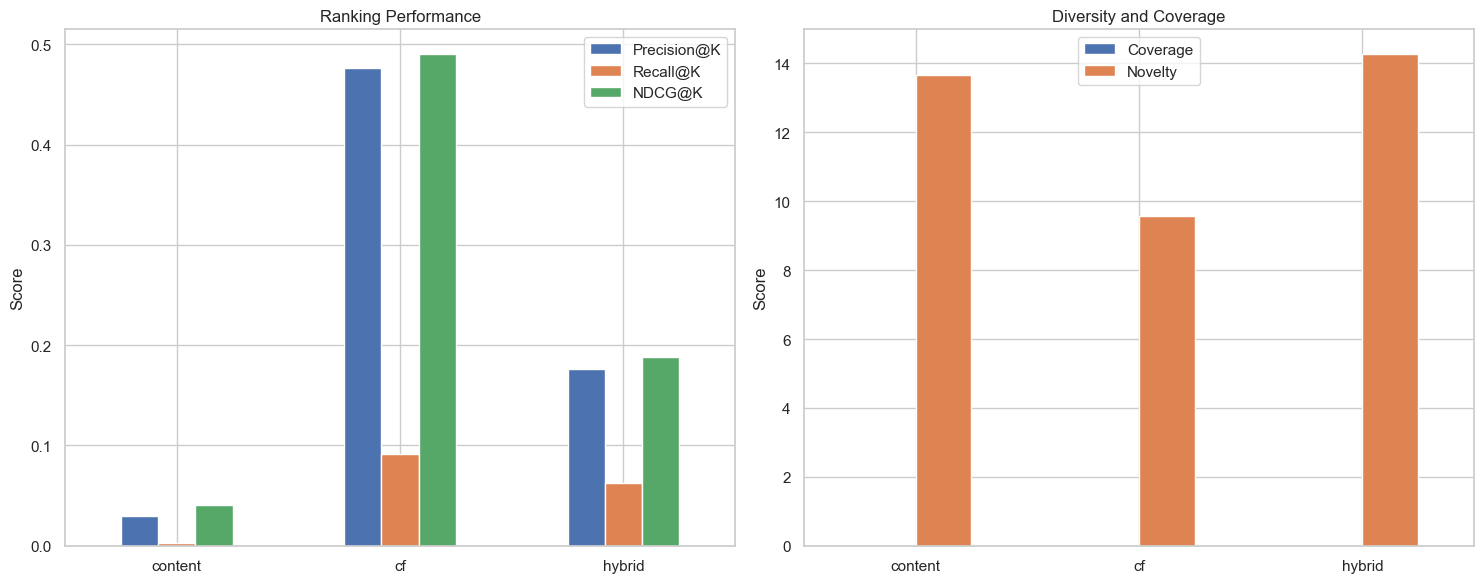

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ranking Metrics
evaluation_results[["Precision@K", "Recall@K", "NDCG@K"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Ranking Performance")
axes[0].set_ylabel("Score")
axes[0].set_xticklabels(evaluation_results.index, rotation=0)

# Diversity Metrics
evaluation_results[["Coverage", "Novelty"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Diversity and Coverage")
axes[1].set_ylabel("Score")
axes[1].set_xticklabels(evaluation_results.index, rotation=0)

plt.tight_layout()
plt.show()